# PyTorch DNN model

## Notebook setup

### Imports

In [1]:
# Standard library imports
import pickle

# Third party imports
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets

# Package imports
from image_classification_tools.pytorch import DataPipeline
import image_classification_tools.pytorch.evaluation as eval_utils
import image_classification_tools.pytorch.plotting as plots
import image_classification_tools.pytorch.training as training

# Local imports
import configuration as config
import helper_functions as hf

Using device: cuda


### Hyperparameters

In [2]:
# Model control
retrain_model = False        # Set to False to load existing model
model_source = 'huggingface' # 'local' or 'huggingface'

# Training parameters
preload_device = 'gpu' if torch.cuda.is_available() else 'cpu'
learning_rate = 1e-3
epochs = 500
early_stopping_patience = 15
print_every = 10

## 1. Load and prepare CIFAR-10 data

### 1.1. Plot sample images

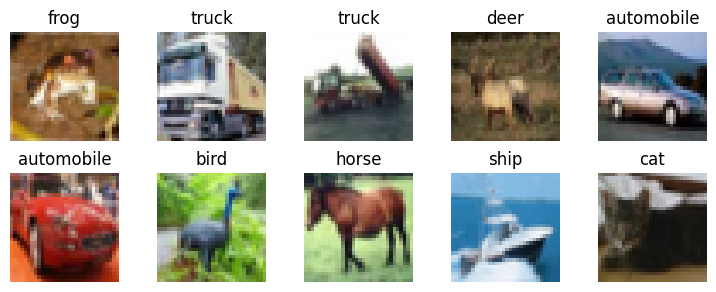

In [3]:
# Get a sample dataset for visualization
sample_dataset = datasets.CIFAR10(root=config.DATA_DIR, transform=config.RGB_TRANSFORM)

# Plot first 10 images from the training dataset
fig, axes = plots.plot_sample_images(sample_dataset, config.CLASS_NAMES)
plt.show()

### 1.2. Create data pipeline with grayscale preprocessing

In [4]:
# Create data pipeline with grayscale preprocessing
loaders = DataPipeline(
    data_source=datasets.CIFAR10,
    split=config.SPLIT,
    train_transform=config.GRAYSCALE_TRANSFORM,
    eval_transform=config.GRAYSCALE_TRANSFORM,
    preload=preload_device,
    batch_size=config.BATCH_SIZE,
    val_size=config.VAL_SIZE,
    seed=config.SEED,
    root=config.DATA_DIR
).get_loaders()

# Display pipeline summary
print(f'\nBatch sizes: {loaders.get_batch_sizes()}')
print(f'Total samples: {loaders.total_samples()}')

memory_estimate = loaders.memory_estimate()

if memory_estimate is not None:
    print(f'Memory estimate: {memory_estimate:.2f} GB')

else:
    print('Memory estimate: N/A')

Loading train dataset...
Loading test dataset...
Creating splits...
Preloading train to GPU:0...


Preloading train: 100%|██████████| 40000/40000 [00:15<00:00, 2539.30it/s]


Preloading val to GPU:0...


Preloading val: 100%|██████████| 10000/10000 [00:03<00:00, 2638.11it/s]



Batch sizes: {'train': 128, 'val': 128, 'test': 128}
Total samples: {'train': 40000, 'val': 10000, 'test': 10000}
Memory estimate: 0.69 GB


In [5]:
# Unpack loaders for convenience
train_loader = loaders.train
val_loader = loaders.val
test_loader = loaders.test

In [6]:
# Define model path
model_path = config.MODELS_DIR / 'dnn.pth'

# Load existing model if requested
if not retrain_model:

    model = hf.load_model_from_source(
        model_path=model_path,
        model_name='dnn.pth',
        model_source=model_source,
        device=config.DEVICE
    )
    
    # Try to load training history
    history = hf.load_history_from_source(
        model_path=model_path,
        model_name='dnn.pth',
        model_source=model_source
    )
    
    if model is None:
        print('Pretrained model not available, proceeding with training...')
        retrain_model = True
else:
    print('Training new model...')
    history = None

Model downloaded from Hugging Face
Training history downloaded from Hugging Face (pickle format)


### 2.1. Define model architecture

In [7]:
if retrain_model:

    # Input size: 1 x 32 x 32 = 1024 (grayscale)
    model = nn.Sequential(
        nn.Flatten(),
        nn.Dropout(0.5),
        nn.Linear(1024, 1024),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(1024, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, 64),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(64, len(config.CLASS_NAMES))
    ).to(config.DEVICE)

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(model)
    print(f'\nTotal parameters: {trainable_params}')

### 2.2. Define loss function and optimizer

In [8]:
if retrain_model:
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

### 2.3. Train model

In [9]:
%%time

if retrain_model:
    history = training.train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=config.DEVICE,
        epochs=epochs,
        print_every=print_every,
        enable_early_stopping=True,
        early_stopping_patience=early_stopping_patience
    )

    print()
else:
    print('Training skipped - using loaded model\n')

Training skipped - using loaded model

CPU times: user 97 µs, sys: 0 ns, total: 97 µs
Wall time: 87.3 µs


### 2.5. Learning curves

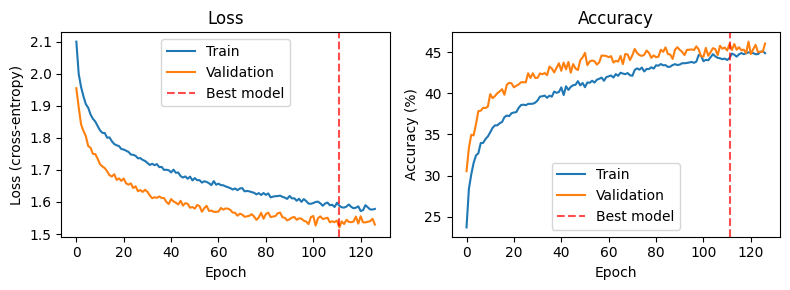

In [10]:
fig, axes = plots.plot_learning_curves(history)
plt.show()

## 3. Evaluate model on test set

### 3.1. Calculate test accuracy

In [11]:
test_accuracy, predictions, true_labels = eval_utils.evaluate_model(model, test_loader)
print(f'Test accuracy: {test_accuracy:.2f}%')

Test accuracy: 46.33%


### 3.2. Per-class accuracy

In [12]:
# Calculate per-class accuracy
class_correct = {name: 0 for name in config.CLASS_NAMES}
class_total = {name: 0 for name in config.CLASS_NAMES}

for pred, true in zip(predictions, true_labels):

    class_name = config.CLASS_NAMES[true]
    class_total[class_name] += 1

    if pred == true:
        class_correct[class_name] += 1

print('Per-class accuracy:')
print('-' * 30)

for name in config.CLASS_NAMES:
    acc = 100 * class_correct[name] / class_total[name]
    print(f'{name:12s}: {acc:.2f}%')

Per-class accuracy:
------------------------------
airplane    : 34.40%
automobile  : 55.80%
bird        : 43.30%
cat         : 32.30%
deer        : 38.80%
dog         : 32.10%
frog        : 60.20%
horse       : 50.30%
ship        : 68.60%
truck       : 47.50%


### 3.4. Confusion matrix

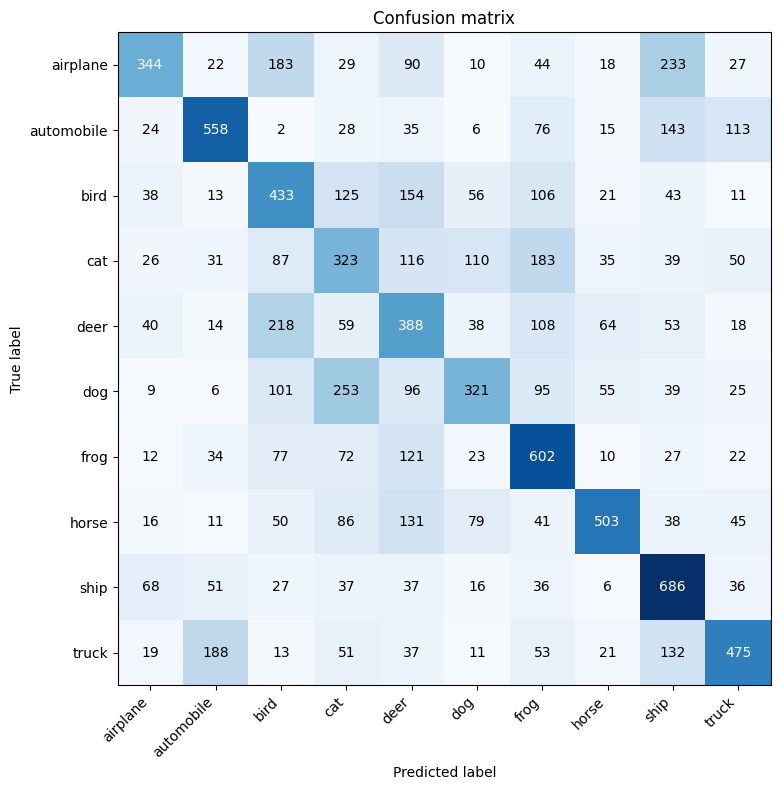

In [13]:
fig, ax = plots.plot_confusion_matrix(true_labels, predictions, config.CLASS_NAMES)
plt.show()

### 3.5. Predicted class probability distributions

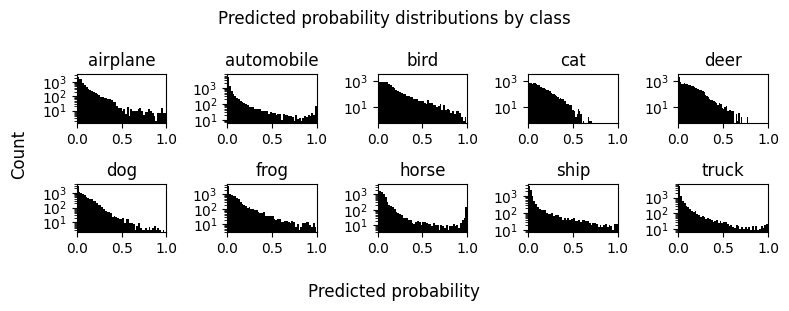

In [14]:
# Get predicted probabilities for all test samples
model.eval()
all_probs = []

with torch.no_grad():
    for images, _ in test_loader:

        outputs = model(images.to(config.DEVICE))
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())

all_probs = np.concatenate(all_probs, axis=0)

# Plot probability distributions
fig, axes = plots.plot_class_probability_distributions(all_probs, config.CLASS_NAMES)
plt.show()

### 3.6. Evaluation curves

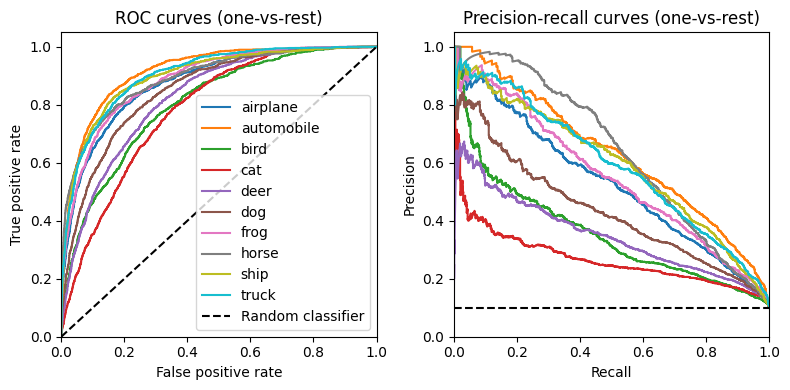

In [15]:
fig, (ax1, ax2) = plots.plot_evaluation_curves(true_labels, all_probs, config.CLASS_NAMES)
plt.show()

## 4. Save model

In [16]:
if retrain_model:

    # Save trained model (and auto-upload to Hugging Face if configured)
    hf.save_and_upload_model(
        model=model,
        model_path=model_path,
        model_name='dnn.pth',
        history=history
    )

## 5. Save test results for comparison

In [17]:
# Save performance results
results_path = config.RESULTS_DIR / 'dnn_results.pkl'

# Count model parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Create results dictionary
results_dict = {
    'true_labels': true_labels,
    'predictions': predictions,
    'all_probs': all_probs,
    'test_accuracy': test_accuracy,
    'total_params': total_params,
    'trainable_params': trainable_params
}

# Save results
with open(results_path, 'wb') as f:
    pickle.dump(results_dict, f)

print(f'Test results saved to: {results_path}')
print(f'  - Test accuracy: {test_accuracy:.2f}%')
print(f'  - Trainable parameters: {trainable_params:,}')
print(f'  - Total parameters: {total_params:,}')

Test results saved to: ../data/pytorch/performance_results/dnn_results.pkl
  - Test accuracy: 46.33%
  - Trainable parameters: 1,329,098
  - Total parameters: 1,329,098
